<a href="https://colab.research.google.com/github/tasnimanisa2024-star/Employee-Health-Risk-Analysis/blob/main/Employee_Health_Prediction2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv("employee_health_dataset_1000.csv")

print(df.head())
print(df.shape)
print(df.dtypes)

   Age  Gender    Job Role  Work Experience  Working Hours  Overtime Hours  \
0   46    Male  Supervisor              8.7             11               1   
1   32    Male     Ironing             15.7              8               2   
2   25    Male   Packaging              9.8              9               3   
3   38  Female   Packaging             10.2              8               0   
4   36    Male   Packaging              4.5             11               2   

   Workload Level  Stress Level  Anxiety Level  Job Satisfaction  ...  \
0             2.0           3.0              3               3.0  ...   
1             4.0           3.0              4               1.0  ...   
2             3.0           4.0              3               3.0  ...   
3             3.0           4.0              3               3.0  ...   
4             4.0           4.0              2               3.0  ...   

   Noise Level  Temperature  sleep_hours_per_day hypertension_history   bmi  \
0         55.

In [17]:
print(df.isnull().sum())

Age                      0
Gender                   0
Job Role                 0
Work Experience          0
Working Hours            0
Overtime Hours           0
Workload Level          47
Stress Level            42
Anxiety Level            0
Job Satisfaction        59
Physical Activity        0
Break Frequency          0
Fatigue Level            0
Safety Condition         0
Noise Level              0
Temperature              0
sleep_hours_per_day      0
hypertension_history     0
bmi                      0
systolic_bp              0
diastolic_bp             0
cholesterol_total        0
heart_rate               0
Health risk score        0
dtype: int64


In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [19]:
missing_cols = ['Workload Level', 'Stress Level', 'Job Satisfaction']

for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
df['Target_Risk'] = df['Health risk score'].apply(lambda x: 1 if x >= 50 else 0)
df = df.drop(columns=['Health risk score'])

In [21]:

# Overtime ratio
df["overtime_ratio"] = df["Overtime Hours"] / (df["Working Hours"] + 1)

# Blood pressure risk
df["bp_risk"] = np.where(
    (df["systolic_bp"] >= 140) | (df["diastolic_bp"] >= 90),
    1,
    0
)

# Sleep deficit
df["sleep_deficit"] = np.where(
    df["sleep_hours_per_day"] < 7,
    7 - df["sleep_hours_per_day"],
    0
)

# Work pressure index
df["work_pressure_index"] = (
    df["Working Hours"] +
    df["Overtime Hours"] +
    df["Workload Level"].fillna(df["Workload Level"].median()) +
    df["Stress Level"].fillna(df["Stress Level"].median())
)

# BMI category
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

print(df.head())

   Age  Gender    Job Role  Work Experience  Working Hours  Overtime Hours  \
0   46    Male  Supervisor              8.7             11               1   
1   32    Male     Ironing             15.7              8               2   
2   25    Male   Packaging              9.8              9               3   
3   38  Female   Packaging             10.2              8               0   
4   36    Male   Packaging              4.5             11               2   

   Workload Level  Stress Level  Anxiety Level  Job Satisfaction  ...  \
0             2.0           3.0              3               3.0  ...   
1             4.0           3.0              4               1.0  ...   
2             3.0           4.0              3               3.0  ...   
3             3.0           4.0              3               3.0  ...   
4             4.0           4.0              2               3.0  ...   

   systolic_bp  diastolic_bp  cholesterol_total heart_rate  Target_Risk  \
0          134   

In [22]:
X = df.drop(columns=["Target_Risk"])
y = df["Target_Risk"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Gender', 'Job Role', 'Safety Condition', 'bmi_category']
Numeric columns: ['Age', 'Work Experience', 'Working Hours', 'Overtime Hours', 'Workload Level', 'Stress Level', 'Anxiety Level', 'Job Satisfaction', 'Physical Activity', 'Break Frequency', 'Fatigue Level', 'Noise Level', 'Temperature', 'sleep_hours_per_day', 'hypertension_history', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_total', 'heart_rate', 'overtime_ratio', 'bp_risk', 'sleep_deficit', 'work_pressure_index']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Numeric columns: missing values will be replaced by median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical columns: missing values will be replaced by most frequent value,
# then converted into numerical dummy columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing rules
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [26]:

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

param_grids = {
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 8, 10, 12, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 3, 5],
        "model__max_features": ["sqrt", "log2"]
    },

    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 150, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_leaf": [1, 3, 5],
        "model__subsample": [0.8, 1.0]
    },

    "XGBoost": {
        "model__n_estimators": [100, 150, 200, 300],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__min_child_weight": [1, 3, 5]
    }
}

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [33]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count != 0 else 1

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )
}

param_grids = {
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 8, 10, 12, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 3, 5],
        "model__max_features": ["sqrt", "log2"]
    },

    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 150, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_leaf": [1, 3, 5],
        "model__subsample": [0.8, 1.0]
    },

    "XGBoost": {
        "model__n_estimators": [100, 150, 200, 300],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__min_child_weight": [1, 3, 5]
    }
}



In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

best_models = {}
results = []

for name, model in models.items():

    print("\n" + "="*70)
    print(f"Training Model: {name}")
    print("="*70)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=20,
        scoring="accuracy",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    print("Best Parameters:")
    print(search.best_params_)

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Training Model: Decision Tree
Best Parameters:
{'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__criterion': 'gini'}

Accuracy  : 0.7850
Precision : 0.3125
Recall    : 0.3226
F1 Score  : 0.3175
ROC-AUC   : 0.5964

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       169
           1       0.31      0.32      0.32        31

    accuracy                           0.79       200
   macro avg       0.59      0.60      0.59       200
weighted avg       0.79      0.79      0.79       200

Confusion Matrix:
[[147  22]
 [ 21  10]]

Training Model: Random Forest
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': None}

Accuracy  : 0.8650
Precision : 0.6250
Recall    : 0.3226
F1 Score  : 0.4255
ROC-AUC   : 0.8005

Classification Report:
              precision    recall 

In [35]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nFinal Model Comparison:")
display(results_df)


# Percentage version
results_percent = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]:
    results_percent[col] = (results_percent[col] * 100).round(2)

print("\nFinal Model Comparison in Percentage:")
display(results_percent)


Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.865,0.6250,0.322581,0.425532,0.800534
2,Gradient Boosting,0.865,0.7500,0.193548,0.307692,0.819049
3,XGBoost,0.845,0.5000,0.354839,0.415094,0.782783
0,Decision Tree,0.785,0.3125,0.322581,0.317460,0.596392



Final Model Comparison in Percentage:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,86.5,62.50,32.26,42.55,80.05
2,Gradient Boosting,86.5,75.00,19.35,30.77,81.90
3,XGBoost,84.5,50.00,35.48,41.51,78.28
0,Decision Tree,78.5,31.25,32.26,31.75,59.64


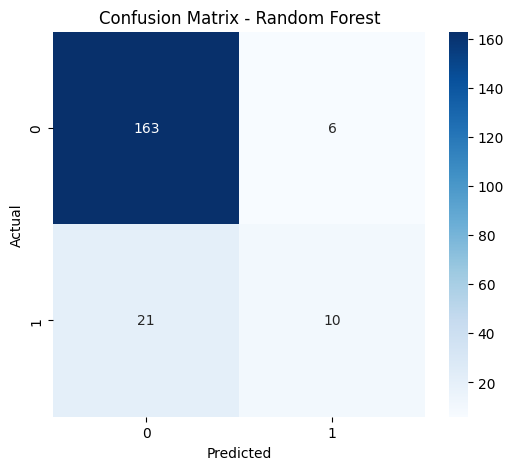

In [36]:
best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

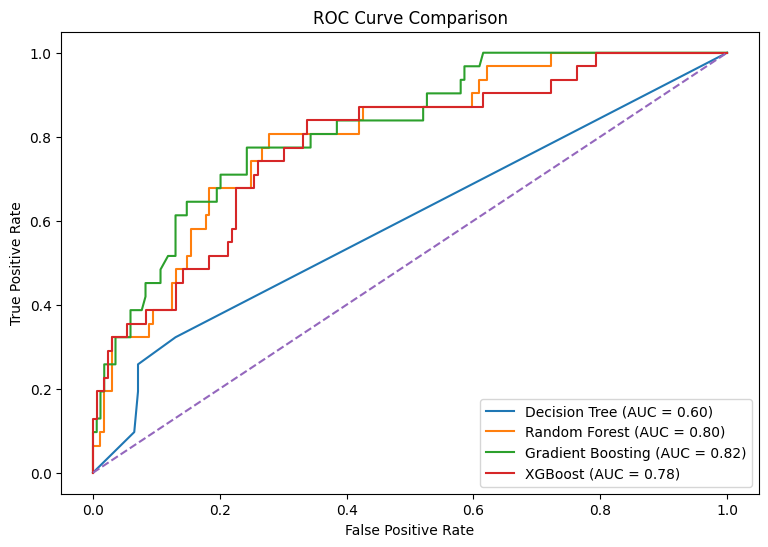

In [37]:
plt.figure(figsize=(9, 6))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()